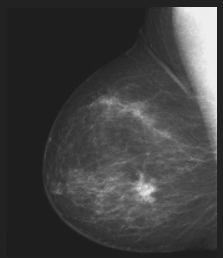

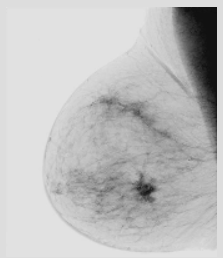

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img_path = "/content/khối u.png"
img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

L = 256
img_neg = L - 1 - img

cv2_imshow(img)
cv2_imshow(img_neg)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
print(img[20,20])

30


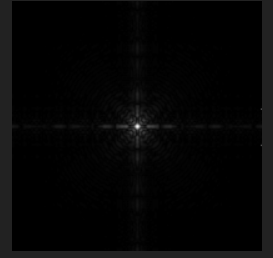

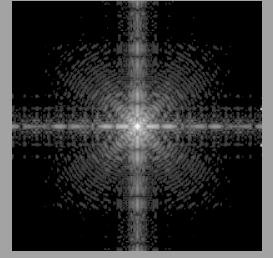

In [ ]:
import numpy as np

img_path = "/content/cham sang.png"
img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

c = 255/(np.log(255+1))
img_log = np.uint8(c * np.log(img+1.0))

cv2_imshow(img)
cv2_imshow(img_log)

cv2.waitKey(0)
cv2.destroyAllWindows()

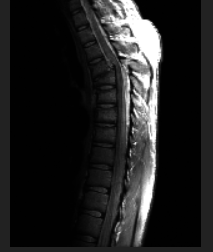

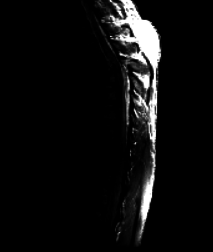

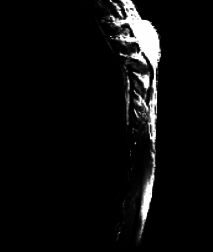

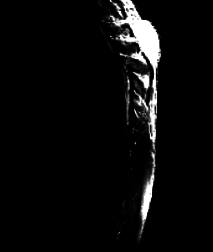

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img_path = "/content/xuong.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

def GrammaTransform(img, gramma):
    W, H = img.shape
    img_gramma = np.zeros((W, H), np.uint8)
    c = np.power(255, 1 - gramma)
    for x in range(0, W):
        for y in range(0, H):
            r = img[x, y]
            s = c * np.power(r, gramma)
            img_gramma[x, y] = np.uint8(s)
    return img_gramma

img_gramma_1 = GrammaTransform(img, 3.0)
img_gramma_2 = GrammaTransform(img, 4.0)
img_gramma_3 = GrammaTransform(img, 5.0)

cv2_imshow(img)
cv2_imshow(img_gramma_1)
cv2_imshow(img_gramma_2)
cv2_imshow(img_gramma_3)
cv2.waitKey(0)
cv2.destroyAllWindows()

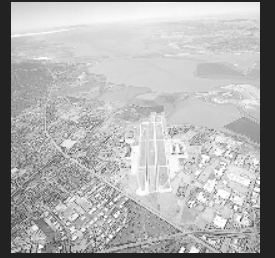

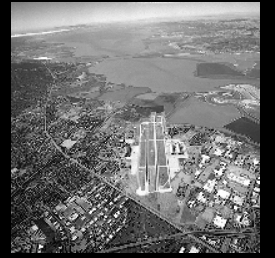

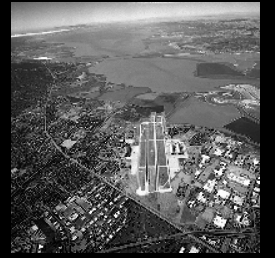

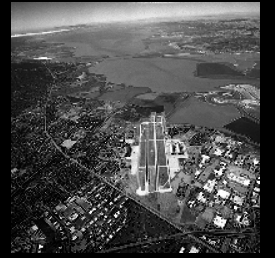

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img_path = "/content/city.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

def GrammaTransform(img, gramma):
    W, H = img.shape
    img_gramma = np.zeros((W, H), np.uint8)
    c = np.power(255, 1 - gramma)
    for x in range(0, W):
        for y in range(0, H):
            r = img[x, y]
            s = c * np.power(r, gramma)
            img_gramma[x, y] = np.uint8(s)
    return img_gramma

img_gramma_1 = GrammaTransform(img, 3.0)
img_gramma_2 = GrammaTransform(img, 4.0)
img_gramma_3 = GrammaTransform(img, 5.0)

cv2_imshow(img)
cv2_imshow(img_gramma_1)
cv2_imshow(img_gramma_2)
cv2_imshow(img_gramma_3)
cv2.waitKey(0)
cv2.destroyAllWindows()

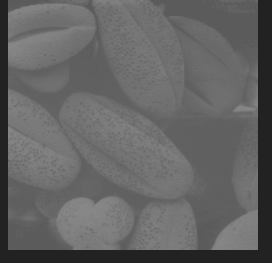

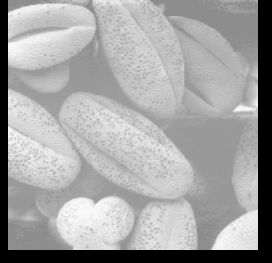

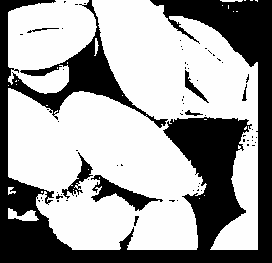

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img_path = "/content/hatgao.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

rmin = np.min(img)
rmax = np.max(img)
rmean = np.mean(img)

def ContrastStretching(img, r1, r2, s1, s2):
    W, H = img.shape
    img_contrast = np.zeros((W, H), np.uint8)
    for x in range(0, W):
        for y in range(0, H):
            r = img[x, y]
            if (r <= r1):
                # Thêm kiểm tra r1 == 0 để tránh lỗi chia cho 0
                s = (s1/r1)*r if r1 != 0 else 0
            elif ((r > r1) & (r <= r2)):
                s = (s2 - s1)/(r2 - r1)*r + (s1*r2 - s2*r1)/(r2 - r1)
            else:
                s = (255 - s2)/(255 - r2)*r + (255*(s2 - r2))/(255 - r2)

            img_contrast[x, y] = np.uint8(s)
    return img_contrast

img_contrast = ContrastStretching(img, rmin, rmax, 0.0, 255.0)
img_threshold = ContrastStretching(img, rmean, rmean, 0.0, 255.0)

# ==================== PHẦN BỔ SUNG HIỂN THỊ ============
# 1. Tạo các cửa sổ hiển thị ảnh
cv2_imshow(img)
cv2_imshow(img_contrast)
cv2_imshow(img_threshold)

# 2. Chờ người dùng nhấn một phím bất kỳ trên bàn phím để đóng cửa sổ
cv2.waitKey(0)

# 3. Giải phóng bộ nhớ và đóng toàn bộ cửa sổ OpenCV
cv2.destroyAllWindows()

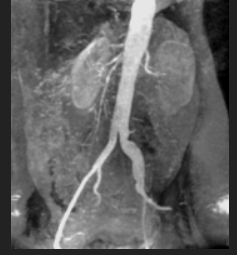

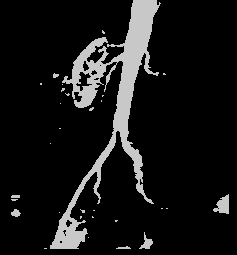

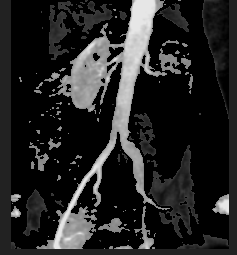

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img_path = "/content/than.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

rmean = np.mean(img)
W, H = img.shape
img_slicing_1 = np.zeros((W, H), np.uint8)
img_slicing_2 = img.copy()

for x in range(0, W):
    for y in range(0, H):
        r = img[x, y]
        if ((r >= 150) & (r <= 255)):
            img_slicing_1[x, y] = 200
        if ((r >= (rmean - 35)) & (r <= (rmean + 35))):
            img_slicing_2[x, y] = 0

cv2_imshow(img)
cv2_imshow(img_slicing_1)
cv2_imshow( img_slicing_2)

cv2.waitKey(0)
cv2.destroyAllWindows()

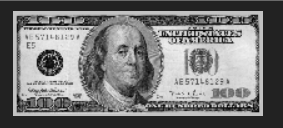

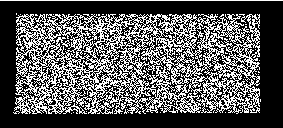

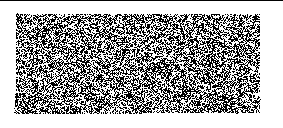

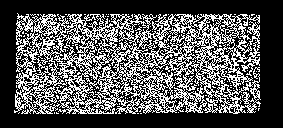

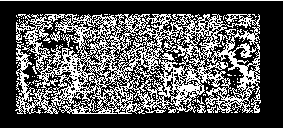

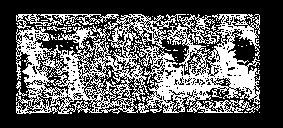

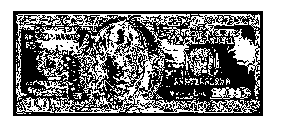

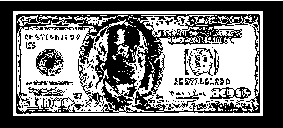

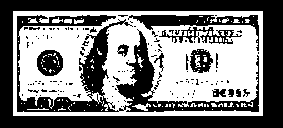

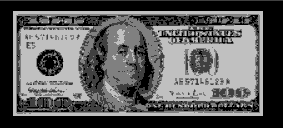

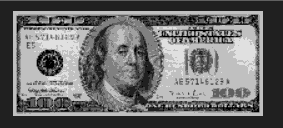

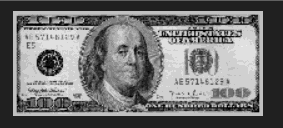

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img_path = "/content/tiendo.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

W, H = img.shape
bit_plane = [np.zeros((W, H), np.uint8) for _ in range(11)]

for x in range(W):
    for y in range(H):
        r = img[x, y]
        for z in range(8):
            mask = (1 << z)
            bit_value = (r & mask) >> z
            bit_plane[z][x, y] = bit_value * 255

bit_plane[8] = ((bit_plane[7]/255)*2**7 + (bit_plane[6]/255)*2**6).astype(np.uint8)
bit_plane[9] = (bit_plane[8] + (bit_plane[5]/255)*2**5).astype(np.uint8)
bit_plane[10] = (bit_plane[9] + (bit_plane[4]/255)*2**4).astype(np.uint8)

cv2_imshow(img)
for z in range(8):
    cv2_imshow(bit_plane[z])
cv2_imshow(bit_plane[8])
cv2_imshow(bit_plane[9])
cv2_imshow(bit_plane[10])
